# Tutorial PXCT data analysis (PART 1)

### Tutor: Julio C. da Silva (Néel Institute CNRS, Grenoble, France) 
### email: julio-cesar.da-silva@neel.cnrs.fr
#### Personal webpage: https://sites.google.com/view/jcesardasilva

### <span style="color:red">** Disclaimer: This notebook is intended from educational reasons only.**</span>

<table class="tfo-notebook-buttons" align="center">
  <td>
    <a target="_blank" rel="noopener noreferrer" href="https://github.com/jcesardasilva/toupy"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

**All the steps of this processing pipeline are described in:**

*da Silva, J. C., Haubrich, J., Requena, G., Hubert, M., Pacureanu, A., Bloch, L., Yang, Y., Cloetens, P., “High energy near-and far-field ptychographic tomography at the ESRF”. Proc. SPIE 10391, Developments in X-Ray Tomography XI, 1039106 (2017). [doi: 10.1117/12.2272971](https://doi.org/10.1117/12.2272971)*

**REMARKS: the references of this paper contains a list of important and more pioneering works on the PXCT data processing steps**

### Toupy - Tomographic Utilities for Python

<table class="tfo-notebook-buttons" align="center">

  <td>
    <a target="_blank" rel="noopener noreferrer"
href="https://toupy.readthedocs.io"><img src="https://toupy.readthedocs.io/en/latest/_static/toupy_logo.png" width="20%"/></a>
  </td>
</table>

**For the PXCT data analysis, we will use the python suite [*Toupy*](https://toupy.readthedocs.io/), which is maintained by me, but open to contributions from the community.**

In [1]:
#!pip install --user git+https://github.com/jcesardasilva/toupy.git# uncomment this line if not installed

### Setting up the interactive backend

We first activate the interactive matplotlib backend. This is required for the interactive GUI tools in Toupy (phase ramp correction, mask drawing, region picker) to work inside JupyterLab.

> **If you see an error about `ipympl`**, install it once with:
> ```
> pip install ipympl
> ```
> then restart the kernel and re-run from the top.

In [ ]:
%matplotlib widget

Importing the dependencies:

In [ ]:
# standard packages
import os
import tarfile
import sys
# third party packages
import matplotlib.pyplot as plt
import numpy as np
import toupy

#### Loading the data

We will work with a dataset acquired at the **cSAXS beamline** (Paul Scherrer Institut, Switzerland) using **Ptychographic X-ray Computed Tomography (PXCT)**.

**What is PXCT?**
PXCT is a synchrotron X-ray imaging technique that combines:
- **Ptychography**: a coherent diffraction imaging method that recovers the complex-valued transmission of each 2-D projection (both amplitude and phase) with nanometric resolution.
- **Computed Tomography (CT)**: rotating the sample through many angles and reconstructing the 3-D volume from the 2-D projections.

The result is a quantitative 3-D map of the X-ray refractive index decrement δ of the sample — a physically meaningful quantity that can be related to electron density and chemical composition.

**Sample**: A shaped **Fluid Catalytic Cracking (FCC) catalyst** particle. FCC catalysts are industrial shaped catalysts used in oil refineries to convert crude oil into more valuable products (gasoline, olefins). Understanding their 3-D pore structure at the nanoscale is key to optimising their performance.

The open-access publication describing this dataset is:

> *da Silva, J. C., Mader, K., Holler, M., Haberthür, D., Diaz, A., Guizar-Sicairos, M., Cheng, W-C., Shu, Y., Raabe, J., Menzel, A., van Bokhoven, J. A., "Assessment of the 3D pore structure and individual components of preshaped catalyst bodies by X-ray imaging", **ChemCatChem 7**, 413–416 (2015). [doi:10.1002/cctc.201402925](https://doi.org/10.1002/cctc.201402925)*

The data are stored in `PXCTprojections.npz`. Download it from Zenodo (cell above) if not yet present.

In [ ]:
# Download the dataset from Zenodo (run this cell only once)
# Requires: pip install zenodo-get
import subprocess, sys

zenodoID = '15364581'
fname = "PXCTprojections.npz"

import os
if os.path.exists(fname):
    print(f"✓ '{fname}' already present — skipping download.")
else:
    print(f"Downloading dataset {zenodoID} from Zenodo …")
    subprocess.check_call([sys.executable, "-m", "zenodo_get", zenodoID])
    print("Download complete.")

<span style="color:red"> **Remark:**
For the sake of speed and to reduce the computing resources required for this tutorial, the projections have been downsized (binned) by a factor 2, which also means the pixel size is twice larger than the original pixel size. Nevertheless, this does not affect the data processing step, which should be identical for the original dataset. </span>

We can now load the data from the file:

In [4]:
fname = "PXCTprojections.npz"
data_dict = np.load(fname) # load the file
list(data_dict.files) # this one list the keys of the data dictionary extracted from the file

['wavelen', 'psize', 'projections', 'theta']

You can, for example, get the wavelength of the pixel size:

In [5]:
wavelen = data_dict['wavelen']
pixsize = data_dict['psize']

print(f"The projection pixel size of the projections is {pixsize/1e-9:.02f} nm")
print(f"The wavelenth of the incoming photons is {wavelen/1e-10:.02f} Angstroms")

The projection pixel size of the projections is 28.64 nm
The wavelenth of the incoming photons is 2.00 Angstroms


We should also get the tomographic angles (`theta`) and the complex-valued projections, from which we should extract only the phases:

In [6]:
theta = data_dict['theta']
projections = data_dict['projections'] # <- ATTENTION: this one is memory consuming. 
projections = np.angle(projections).astype(np.float32) # Get the phases of the complex-valued projections 
nproj, nr, nc = projections.shape

In [7]:
delta_theta = np.diff(np.sort(theta))[0]
delta_theta_subtomo = np.diff(theta)[0]
print(f"The angular sampling interval is {delta_theta:.02f} degrees")
print(f"The angular sampling interval within each subtomo is {delta_theta_subtomo:.02f} degrees")

The angular sampling interval is 0.40 degrees
The angular sampling interval within each subtomo is 3.20 degrees


In [ ]:
fig0, ax0 = plt.subplots(figsize=(7, 3), constrained_layout=True)
ax0.plot(theta, 'ro', markersize=4)
ax0.set_xlabel('Projection number')
ax0.set_ylabel('Angle (degrees)')
ax0.set_title('Angular sampling of the tomographic scan')
ax0.grid(True, alpha=0.3)
plt.show()

#### Inspecting the projections

Let us display the first and last projections (at 0° and 180° − Δθ).

The projections are **phase images**: the gray level encodes the X-ray phase shift introduced by the sample. Brighter pixels = smaller (less negative) phase shift; darker pixels = larger phase shift (denser material). You will notice:
- A **linear phase ramp** across the image — this is an artefact of the ptychographic reconstruction that must be corrected.
- The **sample** appears as a roughly circular darker region in the centre.
- The **air region** (outside the sample) should ideally be zero but shows the ramp.

In [ ]:
plt.close('all')
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
im1 = ax1.imshow(projections[0], cmap='bone', vmin=-4, vmax=1)
ax1.set_title('Phase proj. at 0°', fontsize=13)
ax1.axis('off')
im2 = ax2.imshow(projections[-1], cmap='bone', vmin=-4, vmax=1)
ax2.set_title(f'Phase proj. at {theta[-1]:.1f}°', fontsize=13)
ax2.axis('off')
fig1.colorbar(im1, ax=[ax1, ax2], shrink=0.8, label='Phase shift (rad)')
plt.show()

#### Step 1 — Removing the linear phase ramp

Every ptychographic projection carries a **linear phase ramp** (a tilted background) because the absolute phase reference is not measured. If left uncorrected, this ramp would produce strong streak artefacts in the tomographic reconstruction.

**Strategy**: fit and subtract a plane from the **air region** of each projection. The air region (vacuum around the sample) should have zero phase shift — any non-zero value there is the ramp artefact.

We need two things:
1. A **mask** identifying the air pixels in every projection.
2. The `rmlinearphase` function from Toupy that fits and removes the ramp.

**Interactive approach** (recommended): use `make_air_mask` to draw the air region directly on the image. The function opens a figure — click vertices to outline the air areas (left + right sides of the sample), click *Add region* for each polygon, then *Finish*.

**Drawing the air mask interactively**

`make_air_mask` opens an interactive figure. The workflow is:
1. **Cell below**: call `make_air_mask(projections[0], ...)` to open the figure.
2. **Interact**: left-click on the image to place polygon vertices in the *air* region (outside the sample). Click **Add region** to store each polygon, then **Finish** when done.
3. **Next cell**: access `painter.mask` — a boolean array that is `True` in the air region.

> ⚠️ Do **not** put `painter.mask` in the same cell as the `make_air_mask(...)` call. The function returns immediately and the mask is only populated after you click *Finish*.

In [ ]:
from toupy.restoration import make_air_mask

# Cell 1 — opens the interactive mask-drawing figure.
# Left-click to add polygon vertices in the AIR regions (left and right of the sample).
# Click  "Add region"  after each polygon, then  "Finish"  when done.
painter = make_air_mask(projections[0], cmap='bone', vmin=-2, vmax=1)

In [ ]:
# Cell 2 — run this AFTER clicking Finish in the figure above.
maskair = painter.mask.astype(np.float32)
print(f"Air mask: {maskair.sum():.0f} pixels selected out of {maskair.size} ({100*maskair.mean():.1f}%)")

**Fallback: hardcoded mask**

If the interactive mask drawing is not available (e.g. inline backend), you can define the mask manually using the pixel coordinates of the air region visible in the plot above. Adjust the ranges to match what you see:

In [ ]:
# Inspect one projection before ramp removal to identify the air region
projnum = 1  # which projection to inspect
pvmin, pvmax = -2.1, 2.0  # colour scale

import matplotlib.gridspec as gridspec

fig2 = plt.figure(2, figsize=(6, 8), constrained_layout=True)
gs = gridspec.GridSpec(2, 1, height_ratios=[7, 3])
ax1 = plt.subplot(gs[0])
ax1.imshow(projections[projnum], cmap='bone', vmin=pvmin, vmax=pvmax)
ax1.axhline(nr // 2, color='r', linestyle='--', linewidth=1)
ax1.set_xlabel('pixels'); ax1.set_ylabel('pixels')
ax1.set_title(f'Projection {projnum} — before ramp removal', fontsize=12)
ax1.axis('tight')

ax2 = plt.subplot(gs[1])
ax2.plot(projections[projnum, nr // 2, :])
ax2.axhline(0, color='k', linewidth=0.8)
ax2.set_xlim([0, nc]); ax2.set_ylim([pvmin, pvmax])
ax2.set_xlabel('pixels'); ax2.set_ylabel('Phase (rad)')
ax2.set_title('Horizontal profile at mid-height', fontsize=11)
plt.show()

In [ ]:
# Fallback: manually define the air mask if make_air_mask is not available.
# Edit these slice ranges to match the air region in YOUR dataset.
# Use the plot above to identify the pixel coordinates of the air columns.
maskair = np.zeros_like(projections[0], dtype=np.float32)
maskair[100:400, 70:150]  = 1   # left air strip
maskair[100:400, 490:550] = 1   # right air strip
print(f"Manual air mask: {maskair.sum():.0f} pixels ({100*maskair.mean():.1f}%)")

In [ ]:
# Visualise the mask overlaid on the projection (bright = masked air region)
projnum = 1
fig2 = plt.figure(2, figsize=(6, 8), constrained_layout=True)
gs = gridspec.GridSpec(2, 1, height_ratios=[7, 3])
ax1 = plt.subplot(gs[0])
ax1.imshow(projections[projnum] + maskair, cmap='bone', vmin=pvmin, vmax=pvmax)
ax1.axhline(nr // 2, color='r', linestyle='--', linewidth=1)
ax1.set_xlabel('pixels'); ax1.set_ylabel('pixels')
ax1.set_title('Projection + air mask overlay', fontsize=12)
ax1.axis('tight')
ax2 = plt.subplot(gs[1])
ax2.plot(projections[projnum, nr // 2, :])
ax2.axhline(0, color='k', linewidth=0.8)
ax2.set_xlim([0, nc]); ax2.set_ylim([pvmin, pvmax])
ax2.set_xlabel('pixels'); ax2.set_ylabel('Phase (rad)')
plt.show()

#### Applying the linear phase ramp correction

`rmlinearphase` fits a 2-D plane to the phase values at the **masked air pixels** and subtracts it from the whole image. It works on the **complex** representation of the phase — hence the `exp(1j * phase)` conversion.

We first test it on a single projection, then apply it to the whole stack.

In [ ]:
from toupy.restoration import rmlinearphase
from toupy.utils import tqdm

In [ ]:
projnum = 1
pvmin, pvmax = -3, 1

imgin = np.exp(1j * projections[projnum]).copy()
projcorr_test = np.angle(rmlinearphase(imgin, maskair)).copy()

fig2 = plt.figure(2, figsize=(6, 8), constrained_layout=True)
gs = gridspec.GridSpec(2, 1, height_ratios=[7, 3])
ax1 = plt.subplot(gs[0])
ax1.imshow(projcorr_test + maskair, cmap='bone', vmin=pvmin, vmax=pvmax)
ax1.axhline(nr // 2, color='r', linestyle='--', linewidth=1)
ax1.set_xlabel('pixels'); ax1.set_ylabel('pixels')
ax1.set_title(f'Projection {projnum} — AFTER ramp removal', fontsize=12)
ax1.axis('tight')
ax2 = plt.subplot(gs[1])
ax2.plot(projcorr_test[nr // 2, :])
ax2.axhline(0, color='k', linewidth=0.8)
ax2.set_xlim([0, nc]); ax2.set_ylim([pvmin, pvmax])
ax2.set_xlabel('pixels'); ax2.set_ylabel('Phase (rad)')
ax2.set_title('Horizontal profile — ramp removed', fontsize=11)
plt.show()

The linear ramp is gone — the air region is now flat around zero. We can now apply the correction to **all projections**.

In [ ]:
import sys
projcorr = np.empty_like(projections)
for ii in tqdm(range(nproj), desc="Removing phase ramp", colour='blue', file=sys.stdout):
    imgin = np.exp(1j * projections[ii]).copy()
    projcorr[ii] = np.angle(rmlinearphase(imgin, maskair))

In [ ]:
# Spot-check: inspect any projection after correction
projnum = 250
pvmin, pvmax = -3, 1

fig3 = plt.figure(3, figsize=(6, 8), constrained_layout=True)
gs = gridspec.GridSpec(2, 1, height_ratios=[7, 3])
ax1 = plt.subplot(gs[0])
ax1.imshow(projcorr[projnum], cmap='bone', vmin=pvmin, vmax=pvmax)
ax1.axhline(nr // 2, color='r', linestyle='--', linewidth=1)
ax1.set_xlabel('pixels'); ax1.set_ylabel('pixels')
ax1.set_title(f'Projection {projnum} after ramp removal', fontsize=12)
ax1.axis('tight')
ax2 = plt.subplot(gs[1])
ax2.plot(projcorr[projnum, nr // 2, :])
ax2.axhline(0, color='k', linewidth=0.8)
ax2.set_xlim([0, nc]); ax2.set_ylim([pvmin, pvmax])
ax2.set_xlabel('pixels'); ax2.set_ylabel('Phase (rad)')
plt.show()

In [17]:
from toupy.restoration import rmphaseramp, normalize_projections_phase

sinogram = projcorr[:,300,:]
argangle = np.argsort(theta)
sinosort = sinogram[argangle]

corrected, offsets = normalize_projections_phase(projcorr, border=55)
sinogram_norm = corrected[:,300,:]
sinosort_norm = sinogram_norm[argangle]

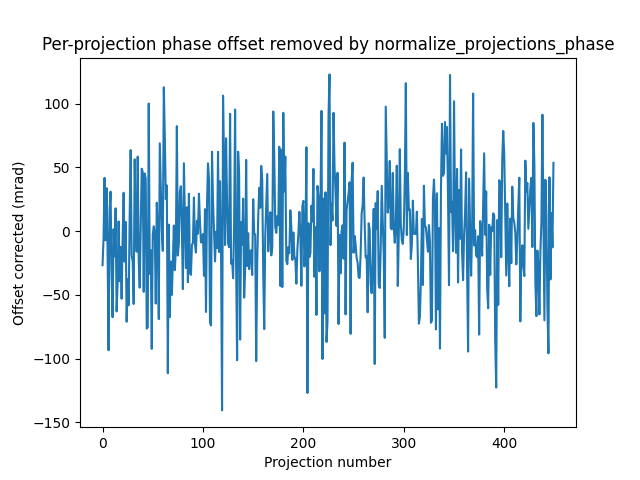

In [18]:
import matplotlib.pyplot as plt
plt.figure(constrained_layout=True)
plt.plot(offsets * 1e3)
plt.xlabel('Projection number')
plt.ylabel('Offset corrected (mrad)')
plt.title('Per-projection phase offset removed by normalize_projections_phase')
plt.show()

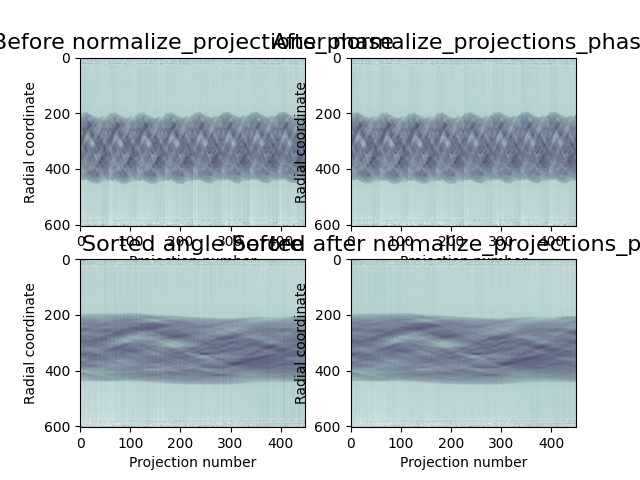

In [19]:
# preparing figure canvas
plt.close('all')
fig4 = plt.figure(4, constrained_layout=True)#, figsize = (12,12))
ax41 = fig4.add_subplot(221)
im41 = ax41.imshow(sinogram.T,cmap='bone', vmin = -4, vmax = 1)
ax41.set_xlabel('Projection number')
ax41.set_ylabel('Radial coordinate')
ax41.set_title('Before normalize_projections_phase', fontsize = 16)
ax41.axis('tight')
ax42 = fig4.add_subplot(222)
im42 = ax42.imshow(sinogram_norm.T,cmap='bone', vmin = -4, vmax = 1)
ax42.set_xlabel('Projection number')
ax42.set_ylabel('Radial coordinate')
ax42.set_title('After normalize_projections_phase', fontsize = 16)
ax42.axis('tight')
ax42 = fig4.add_subplot(223)
im42 = ax42.imshow(sinosort.T,cmap='bone', vmin = -4, vmax = 1)
ax42.set_xlabel('Projection number')
ax42.set_ylabel('Radial coordinate')
ax42.set_title('Sorted angle before', fontsize = 16)
ax42.axis('tight')
ax42 = fig4.add_subplot(224)
im42 = ax42.imshow(sinosort_norm.T,cmap='bone', vmin = -4, vmax = 1)
ax42.set_xlabel('Projection number')
ax42.set_ylabel('Radial coordinate')
ax42.set_title('Sorted after normalize_projections_phase', fontsize = 16)
ax42.axis('tight')
plt.show(block=False)

#### Step 2 — Phase unwrapping

Ptychography recovers phases in the range [−π, π]. When the true phase shift exceeds this range, the image shows abrupt 2π **jumps** (wrapped phase). These jumps create severe artefacts in the tomographic reconstruction and must be corrected.

**Phase unwrapping** is the process of recovering the true, continuous phase from the wrapped measurement. It is a non-trivial problem — especially in 2-D — because noisy or low-coherence regions can cause unwrapping errors that propagate across the image.

The workflow:
1. `chooseregiontounwrap` — opens an interactive GUI to:
   - Identify the rectangular region of interest to unwrap (click top-left, then bottom-right corner).
   - Select a pixel in the **air** region (used to set the absolute phase offset after unwrapping).
2. `unwrapping_phase` — applies the chosen algorithm to all projections.

Several unwrapping algorithms are available (see the next cell for details). The default (`herraez`) works well for most PXCT data.

#### Available 2-D phase unwrapping algorithms

| Method | Key idea | Best for |
|--------|----------|----------|
| `"herraez"` *(default)* | Reliability-guided BFS — unwraps most-reliable pixels first using a min-heap | Most PXCT data; good balance of speed and robustness |
| `"goldstein"` | Locates phase residues, draws branch cuts, then flood-fills | Data with well-localised residues |
| `"flynn"` | Row-by-row integration; corrects row discontinuities | Fastest, but least robust; suitable for very clean data |
| `"wls"` | DCT-based least-squares Poisson solver (Ghiglia & Romero 1994) | Best overall quality; no extra install needed |
| `"snaphu"` | Statistical network-flow (Chen & Zebker 2001) | Gold-standard for noisy / difficult data; requires `pip install snaphu` |

**Recommendation**: start with `"herraez"`. If you see residual wrapping artefacts in the reconstruction, try `"wls"` or `"snaphu"`.

In [ ]:
# Cell 1 — opens the interactive region-picker GUI.
# Click:  (1) top-left corner of the unwrap region
#         (2) bottom-right corner  → blue rectangle appears + residue count printed
#         (3) a pixel in AIR (must be inside the rectangle)
# Then click  Confirm.  Use  Reset  to start over.
from toupy.restoration import chooseregiontounwrap, unwrapping_phase

picker = chooseregiontounwrap(projcorr)

In [ ]:
# Cell 2 — run this AFTER clicking Confirm in the figure above.
rx, ry, airpix = picker.rx, picker.ry, picker.airpix
print(f"Unwrap region: columns {rx[0]}–{rx[-1]}, rows {ry[0]}–{ry[-1]}")
print(f"Air pixel: (col={airpix[0]}, row={airpix[1]})")

In [ ]:
params = dict()
params["unwrap_method"] = "herraez"  # see table above for options
params["parallel"] = True
params["n_cpus"] = -1                # -1 = use all available cores
params["vmin"] = pvmin
params["vmax"] = pvmax
params["snaphu_verbose"] = False

print(f"Unwrapping {nproj} projections using method='{params['unwrap_method']}' …")
projunwrap = unwrapping_phase(projcorr, rx, ry, airpix, **params)
print("✓ Unwrapping complete.")

#### Saving progress

We save the ramp-corrected and unwrapped projections to disk before moving to Part 2.

The file `PXCTcorrprojections.npz` will be the input for Part 2 (alignment).

In [ ]:
outputfname = "PXCTcorrprojections.npz"
np.savez(outputfname, wavelen = wavelen, psize = pixsize, projections = projunwrap, theta = theta)

In [ ]:
!ls -lrth